In [1]:
# Imports & MLflow Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.xgboost
import mlflow.lightgbm
from mlflow.tracking import MlflowClient
import json
import os
import warnings

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi":110,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── MLflow Configuration ─────────────────────────────────────
# For local development, MLflow stores everything in ./mlruns
# In production this would point to a remote tracking server
MLFLOW_TRACKING_URI = "sqlite:///mlruns.db"
EXPERIMENT_NAME     = "naijashield-fraud-detection"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI : {MLFLOW_TRACKING_URI}")
print(f"Experiment name     : {EXPERIMENT_NAME}")
print(f"View UI with       : mlflow ui --backend-store-uri {MLFLOW_TRACKING_URI}")

/home/thedataboy/dev/fraud-detection-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow tracking URI : sqlite:///mlruns.db
Experiment name     : naijashield-fraud-detection
View UI with       : mlflow ui --backend-store-uri sqlite:///mlruns.db


In [2]:
# Load Processed Data

DATA_DIR = "../data/processed"

print("⏳ Loading processed datasets...")

X_train = pd.read_parquet(f"{DATA_DIR}/X_train.parquet")
X_val   = pd.read_parquet(f"{DATA_DIR}/X_val.parquet")
X_test  = pd.read_parquet(f"{DATA_DIR}/X_test.parquet")

y_train = pd.read_parquet(f"{DATA_DIR}/y_train.parquet").squeeze()
y_val   = pd.read_parquet(f"{DATA_DIR}/y_val.parquet").squeeze()
y_test  = pd.read_parquet(f"{DATA_DIR}/y_test.parquet").squeeze()

with open(f"{DATA_DIR}/feature_config.json") as f:
    feature_config = json.load(f)

SCALE_POS_WEIGHT = feature_config["scale_pos_weight"]
FEATURES         = feature_config["features"]

print(f"Data loaded")
print(f"\n  X_train : {X_train.shape[0]:>10,} rows × {X_train.shape[1]} features")
print(f"  X_val   : {X_val.shape[0]:>10,} rows × {X_val.shape[1]} features")
print(f"  X_test  : {X_test.shape[0]:>10,} rows × {X_test.shape[1]} features")
print(f"\n  scale_pos_weight : {SCALE_POS_WEIGHT:.2f}")
print(f"  Train fraud rate : {y_train.mean()*100:.2f}%")
print(f"  Val   fraud rate : {y_val.mean()*100:.2f}%")
print(f"  Test  fraud rate : {y_test.mean()*100:.2f}%")

# ── Align features ───────────────────────────────────────────
# Ensure all splits have the same columns in the same order
X_train = X_train[FEATURES]
X_val   = X_val[FEATURES]
X_test  = X_test[FEATURES]
print(f"\nFeature alignment verified: {len(FEATURES)} features")

⏳ Loading processed datasets...
Data loaded

  X_train :  3,750,000 rows × 58 features
  X_val   :    625,000 rows × 58 features
  X_test  :    625,000 rows × 58 features

  scale_pos_weight : 26.87
  Train fraud rate : 3.59%
  Val   fraud rate : 3.60%
  Test  fraud rate : 3.60%

Feature alignment verified: 58 features


In [3]:
# Evaluation Helper Functions

# Centralise all metric computation so every model is
# evaluated identically. Reduces copy-paste errors and
# ensures fair comparison across experiments.

def find_optimal_threshold(y_true, y_prob, metric="f1"):
    """
    Find the classification threshold that maximises
    the chosen metric on the validation set.

    Why not use 0.5?
    With 3.59% fraud rate, 0.5 is too conservative.
    The model needs a lower threshold to catch more fraud.
    The optimal threshold balances precision vs recall
    based on business cost assumptions.
    """
    thresholds = np.arange(0.01, 0.99, 0.01)
    best_score, best_threshold = 0, 0.5

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, y_pred, zero_division=0)
        if score > best_score:
            best_score     = score
            best_threshold = t

    return best_threshold, best_score


def evaluate_model(
    model_name, y_true, y_prob,
    threshold=None, split_name="Validation"
):
    """
    Compute and display all relevant metrics for a fraud
    detection model at a given probability threshold.

    Returns a dictionary of metrics for MLflow logging.
    """
    # Find optimal threshold if not provided
    if threshold is None:
        threshold, _ = find_optimal_threshold(y_true, y_prob)

    y_pred = (y_prob >= threshold).astype(int)

    # Core metrics
    auc_pr    = average_precision_score(y_true, y_prob)
    auc_roc   = roc_auc_score(y_true, y_prob)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    cm        = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False positive rate

    metrics = {
        "auc_pr":    round(auc_pr, 4),
        "auc_roc":   round(auc_roc, 4),
        "f1":        round(f1, 4),
        "precision": round(precision, 4),
        "recall":    round(recall, 4),
        "fpr":       round(fpr, 4),
        "threshold": round(threshold, 4),
        "tp": int(tp), "fp": int(fp),
        "tn": int(tn), "fn": int(fn),
    }

    # Display
    print(f"\n{'='*65}")
    print(f"  {model_name} — {split_name} Results")
    print(f"{'='*65}")
    
    print(f"  Threshold       : {threshold:.2f}")
    print(f"  AUC-PR          : {auc_pr:.4f}  ← PRIMARY METRIC")
    print(f"  AUC-ROC         : {auc_roc:.4f}")
    print(f"  F1 Score        : {f1:.4f}")
    print(f"  Precision       : {precision:.4f}")
    print(f"  Recall          : {recall:.4f}")
    print(f"  False Pos Rate  : {fpr:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Legit   Fraud")
    print(f"  Actual Legit   {tn:>7,}  {fp:>6,}  (FP = {fpr*100:.1f}% of legit flagged)")
    print(f"  Actual Fraud   {fn:>7,}  {tp:>6,}  (Recall = {recall*100:.1f}% of fraud caught)")

    return metrics


def plot_precision_recall_curve(models_dict, y_true, title=""):
    """
    Plot Precision-Recall curves for multiple models on one chart.
    models_dict: {"Model Name": y_prob_array}
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = ["#E91E63", "#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

    for (name, y_prob), color in zip(models_dict.items(), colors):
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        auc_pr = average_precision_score(y_true, y_prob)

        # PR Curve
        axes[0].plot(
            recall, precision,
            label=f"{name} (AUC-PR={auc_pr:.4f})",
            color=color, linewidth=2
        )

        # Score distribution
        axes[1].hist(
            y_prob, bins=100, alpha=0.5,
            label=name, color=color, density=True
        )

    # Baseline (random classifier at fraud rate)
    baseline = y_true.mean()
    axes[0].axhline(
        baseline, color="gray", linestyle="--",
        alpha=0.7, label=f"Baseline (fraud rate={baseline:.3f})"
    )
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].set_title("Precision-Recall Curves")
    axes[0].legend(fontsize=9)
    axes[0].set_xlim([0, 1])
    axes[0].set_ylim([0, 1])

    axes[1].set_xlabel("Predicted Fraud Probability")
    axes[1].set_ylabel("Density")
    axes[1].set_title("Score Distribution")
    axes[1].legend(fontsize=9)
    axes[1].set_yscale("log")

    if title:
        plt.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


print("Evaluation helper functions defined")
print("find_optimal_threshold()")
print("evaluate_model()")
print("plot_precision_recall_curve()")

Evaluation helper functions defined
find_optimal_threshold()
evaluate_model()
plot_precision_recall_curve()


In [4]:
# XGBoost Baseline

# Why XGBoost?
#   - State of the art on tabular fraud detection benchmarks
#   - Handles missing values natively
#   - scale_pos_weight directly encodes class imbalance
#   - Fast inference (critical for <100ms serving SLA)
#   - Interpretable via SHAP values
#
# Baseline = sensible defaults + correct imbalance handling
# We will tune hyperparameters in a later experiment

XGBOOST_BASELINE_PARAMS = {
    # Class imbalance — from EDA: 26.8:1 ratio
    "scale_pos_weight": SCALE_POS_WEIGHT,

    # Tree structure
    "n_estimators":     500,
    "max_depth":        6,
    "min_child_weight": 5,

    # Learning
    "learning_rate":    0.05,
    "subsample":        0.8,
    "colsample_bytree": 0.8,

    # Regularisation
    "reg_alpha":        0.1,   # L1
    "reg_lambda":       1.0,   # L2

    # Performance
    "tree_method":      "hist",  # Fast histogram method
    "device":           "cpu",
    "n_jobs":           -1,
    "random_state":     42,

    # Evaluation metric during training
    "eval_metric":      "aucpr",  # AUC-PR = our primary metric
    "early_stopping_rounds": 50,
}

print("=" * 65)
print("EXPERIMENT 1: XGBoost Baseline")
print("=" * 65)
print(f"\nParameters:")

for k, v in XGBOOST_BASELINE_PARAMS.items():
    print(f"  {k:<25}: {v}")

with mlflow.start_run(run_name="xgboost-baseline") as run:

    # ── Log parameters ───────────────────────────────────────
    mlflow.log_params(XGBOOST_BASELINE_PARAMS)
    mlflow.log_param("n_train_samples",  len(X_train))
    mlflow.log_param("n_features",       X_train.shape[1])
    mlflow.log_param("train_fraud_rate", round(float(y_train.mean()), 4))
    mlflow.log_param("imbalance_strategy", "scale_pos_weight")

    # ── Train ────────────────────────────────────────────────
    print("\n⏳ Training XGBoost baseline...")
    xgb_model = XGBClassifier(**XGBOOST_BASELINE_PARAMS)

    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=100,  # Print every 100 rounds
    )

    best_iteration = xgb_model.best_iteration
    print(f"\nTraining complete")
    print(f"Best iteration   : {best_iteration}")

    # ── Predict ──────────────────────────────────────────────
    xgb_val_prob  = xgb_model.predict_proba(X_val)[:, 1]
    xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]

    # ── Find optimal threshold on validation set ─────────────
    xgb_threshold, xgb_best_f1 = find_optimal_threshold(
        y_val, xgb_val_prob, metric="f1"
    )

    # ── Evaluate ─────────────────────────────────────────────
    xgb_val_metrics = evaluate_model(
        "XGBoost Baseline", y_val,
        xgb_val_prob, xgb_threshold, "Validation"
    )

    # ── Log metrics to MLflow ────────────────────────────────
    for metric_name, value in xgb_val_metrics.items():
        mlflow.log_metric(f"val_{metric_name}", value)

    mlflow.log_metric("best_iteration", best_iteration)

    # ── Log model to MLflow ──────────────────────────────────
    mlflow.xgboost.log_model(
        xgb_model,
        name="model",
        registered_model_name="naijashield-xgboost",
    )

    XGB_RUN_ID = run.info.run_id
    print(f"\nMLflow run ID: {XGB_RUN_ID}")
    print(f"Model registered as: naijashield-xgboost")

EXPERIMENT 1: XGBoost Baseline

Parameters:
  scale_pos_weight         : 26.872958770319386
  n_estimators             : 500
  max_depth                : 6
  min_child_weight         : 5
  learning_rate            : 0.05
  subsample                : 0.8
  colsample_bytree         : 0.8
  reg_alpha                : 0.1
  reg_lambda               : 1.0
  tree_method              : hist
  device                   : cpu
  n_jobs                   : -1
  random_state             : 42
  eval_metric              : aucpr
  early_stopping_rounds    : 50

⏳ Training XGBoost baseline...
[0]	validation_0-aucpr:0.04384
[100]	validation_0-aucpr:0.04433
[104]	validation_0-aucpr:0.04431

Training complete
Best iteration   : 54

  XGBoost Baseline — Validation Results
  Threshold       : 0.53
  AUC-PR          : 0.0444  ← PRIMARY METRIC
  AUC-ROC         : 0.5969
  F1 Score        : 0.0841
  Precision       : 0.0440
  Recall          : 0.9601
  False Pos Rate  : 0.7793

  Confusion Matrix:
            

2026/04/14 18:37:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



MLflow run ID: 8644f5f4bfe949e2951085fc44523e41
Model registered as: naijashield-xgboost


Registered model 'naijashield-xgboost' already exists. Creating a new version of this model...
Created version '4' of model 'naijashield-xgboost'.


In [5]:
# LightGBM Comparison

# Why LightGBM as well?
#   - Often faster training than XGBoost on large datasets
#   - Leaf-wise tree growth (vs level-wise in XGBoost)
#     → can capture more complex patterns
#   - class_weight parameter for imbalance handling
#   - Worth comparing on 5M row dataset for speed vs accuracy

LGBM_PARAMS = {
    # Class imbalance
    "class_weight":      "balanced",  # LightGBM equivalent

    # Tree structure
    "n_estimators":      500,
    "max_depth":         6,
    "num_leaves":        63,          # 2^max_depth - 1
    "min_child_samples": 50,

    # Learning
    "learning_rate":     0.05,
    "subsample":         0.8,
    "colsample_bytree":  0.8,

    # Regularisation
    "reg_alpha":         0.1,
    "reg_lambda":        1.0,

    # Performance
    "n_jobs":             4,           # Use 4 CPU cores for training
    "random_state":      42,
    "verbose":           -1,          # Suppress LightGBM output
}

print("=" * 65)
print("EXPERIMENT 2: LightGBM Comparison")
print("=" * 65)

with mlflow.start_run(run_name="lightgbm-baseline") as run:

    mlflow.log_params(LGBM_PARAMS)
    mlflow.log_param("imbalance_strategy", "class_weight_balanced")

    print("\n⏳ Training LightGBM...")
    lgbm_model = LGBMClassifier(**LGBM_PARAMS)

    lgbm_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            # Early stopping
            __import__("lightgbm").early_stopping(50, verbose=False),
            __import__("lightgbm").log_evaluation(100),
        ],
    )

    print(f"\nTraining complete")
    print(f"Best iteration: {lgbm_model.best_iteration_}")

    # ── Predict & Evaluate ───────────────────────────────────
    lgbm_val_prob  = lgbm_model.predict_proba(X_val)[:, 1]
    lgbm_test_prob = lgbm_model.predict_proba(X_test)[:, 1]

    lgbm_threshold, _ = find_optimal_threshold(
        y_val, lgbm_val_prob, metric="f1"
    )

    lgbm_val_metrics = evaluate_model(
        "LightGBM Baseline", y_val,
        lgbm_val_prob, lgbm_threshold, "Validation"
    )

    for metric_name, value in lgbm_val_metrics.items():
        mlflow.log_metric(f"val_{metric_name}", value)

    mlflow.lightgbm.log_model(
        lgbm_model,
        name="model",
        registered_model_name="naijashield-lgbm",
    )

    LGBM_RUN_ID = run.info.run_id
    print(f"\nMLflow run ID: {LGBM_RUN_ID}")

EXPERIMENT 2: LightGBM Comparison

⏳ Training LightGBM...
[100]	valid_0's binary_logloss: 0.648406
[200]	valid_0's binary_logloss: 0.6458
[300]	valid_0's binary_logloss: 0.640001
[400]	valid_0's binary_logloss: 0.634915
[500]	valid_0's binary_logloss: 0.631778

Training complete
Best iteration: 500


2026/04/14 18:38:37 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  LightGBM Baseline — Validation Results
  Threshold       : 0.41
  AUC-PR          : 0.0442  ← PRIMARY METRIC
  AUC-ROC         : 0.5945
  F1 Score        : 0.0840
  Precision       : 0.0439
  Recall          : 0.9834
  False Pos Rate  : 0.7997

  Confusion Matrix:
                 Predicted
                 Legit   Fraud
  Actual Legit   120,672  481,833  (FP = 80.0% of legit flagged)
  Actual Fraud       373  22,122  (Recall = 98.3% of fraud caught)


2026/04/14 18:38:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



MLflow run ID: 9206c147355c490fae610d5b60265640


Registered model 'naijashield-lgbm' already exists. Creating a new version of this model...
Created version '4' of model 'naijashield-lgbm'.


In [6]:
# SMOTE Experiment

# SMOTE = Synthetic Minority Oversampling Technique
#
# How it works:
#   For each fraud example, find k nearest fraud neighbours
#   Create synthetic fraud examples by interpolating between them
#   Result: balanced training set
#
# CRITICAL RULES:
#   1. SMOTE only on TRAINING set (never val or test)
#   2. Apply AFTER train/val/test split
#   3. SMOTE creates synthetic data — val/test must stay real
#
# We compare: XGBoost + SMOTE vs XGBoost + scale_pos_weight

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("=" * 65)
print("EXPERIMENT 3: XGBoost + SMOTE")
print("=" * 65)

print(f"\nOriginal training set:")
print(f"  Legitimate : {(y_train==0).sum():>10,}")
print(f"  Fraud      : {(y_train==1).sum():>10,}")
print(f"  Ratio      : {(y_train==0).sum()/(y_train==1).sum():.1f}:1")

print(f"\n⏳ Applying SMOTE (this may take a few minutes on 3.75M rows)...")

# SMOTE with k=5 neighbours, target 10:1 ratio
# We do NOT fully balance (1:1) because:
#   - Full balance drastically inflates training set size
#   - 10:1 is sufficient to reduce class imbalance pressure
#   - Fewer synthetic samples = less risk of overfitting to synthetic data
smote = SMOTE(
    sampling_strategy=0.1,  # fraud:legit = 1:10 after resampling
    k_neighbors=5,
    random_state=42,
    )

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nSMOTE resampled training set:")
print(f"  Legitimate : {(y_train_smote==0).sum():>10,}")
print(f"  Fraud      : {(y_train_smote==1).sum():>10,}")
print(f"  Ratio      : {(y_train_smote==0).sum()/(y_train_smote==1).sum():.1f}:1")
print(f"  New total  : {len(X_train_smote):>10,} rows")

# XGBoost params WITHOUT scale_pos_weight (SMOTE handles imbalance)
XGBOOST_SMOTE_PARAMS = {
    **XGBOOST_BASELINE_PARAMS,
    "scale_pos_weight": 1,  # SMOTE already balanced classes
}

with mlflow.start_run(run_name="xgboost-smote") as run:

    mlflow.log_params(XGBOOST_SMOTE_PARAMS)
    mlflow.log_param("imbalance_strategy", "SMOTE")
    mlflow.log_param("smote_sampling_strategy", 0.1)
    mlflow.log_param("smote_k_neighbors", 5)
    mlflow.log_param("n_train_after_smote", len(X_train_smote))

    print("\n⏳ Training XGBoost on SMOTE data...")
    xgb_smote_model = XGBClassifier(**XGBOOST_SMOTE_PARAMS)

    xgb_smote_model.fit(
        X_train_smote, y_train_smote,
        eval_set=[(X_val, y_val)],
        verbose=100,
    )

    # Evaluate on ORIGINAL validation set (not SMOTE)
    xgb_smote_val_prob = xgb_smote_model.predict_proba(X_val)[:, 1]

    smote_threshold, _ = find_optimal_threshold(
        y_val, xgb_smote_val_prob, metric="f1"
    )

    smote_val_metrics = evaluate_model(
        "XGBoost + SMOTE", y_val,
        xgb_smote_val_prob, smote_threshold, "Validation"
    )

    for metric_name, value in smote_val_metrics.items():
        mlflow.log_metric(f"val_{metric_name}", value)

    mlflow.xgboost.log_model(
        xgb_smote_model,
        name="model",
        registered_model_name="naijashield-xgboost-smote",
    )

    SMOTE_RUN_ID = run.info.run_id

EXPERIMENT 3: XGBoost + SMOTE

Original training set:
  Legitimate :  3,615,461
  Fraud      :    134,539
  Ratio      : 26.9:1

⏳ Applying SMOTE (this may take a few minutes on 3.75M rows)...

SMOTE resampled training set:
  Legitimate :  3,615,461
  Fraud      :    361,546
  Ratio      : 10.0:1
  New total  :  3,977,007 rows

⏳ Training XGBoost on SMOTE data...
[0]	validation_0-aucpr:0.04362
[68]	validation_0-aucpr:0.04408

  XGBoost + SMOTE — Validation Results
  Threshold       : 0.05
  AUC-PR          : 0.0443  ← PRIMARY METRIC
  AUC-ROC         : 0.5944
  F1 Score        : 0.0840
  Precision       : 0.0438
  Recall          : 1.0000
  False Pos Rate  : 0.8144

  Confusion Matrix:
                 Predicted
                 Legit   Fraud
  Actual Legit   111,846  490,659  (FP = 81.4% of legit flagged)
  Actual Fraud         0  22,495  (Recall = 100.0% of fraud caught)


2026/04/14 18:39:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'naijashield-xgboost-smote' already exists. Creating a new version of this model...
Created version '2' of model 'naijashield-xgboost-smote'.


MODEL COMPARISON — VALIDATION SET
                      Imbalance Strategy  auc_pr  auc_roc      f1  precision  recall     fpr  threshold
Model                                                                                                  
XGBoost Baseline        scale_pos_weight  0.0444   0.5969  0.0841     0.0440  0.9601  0.7793       0.53
LightGBM Baseline  class_weight=balanced  0.0442   0.5945  0.0840     0.0439  0.9834  0.7997       0.41
XGBoost + SMOTE               SMOTE 10:1  0.0443   0.5944  0.0840     0.0438  1.0000  0.8144       0.05


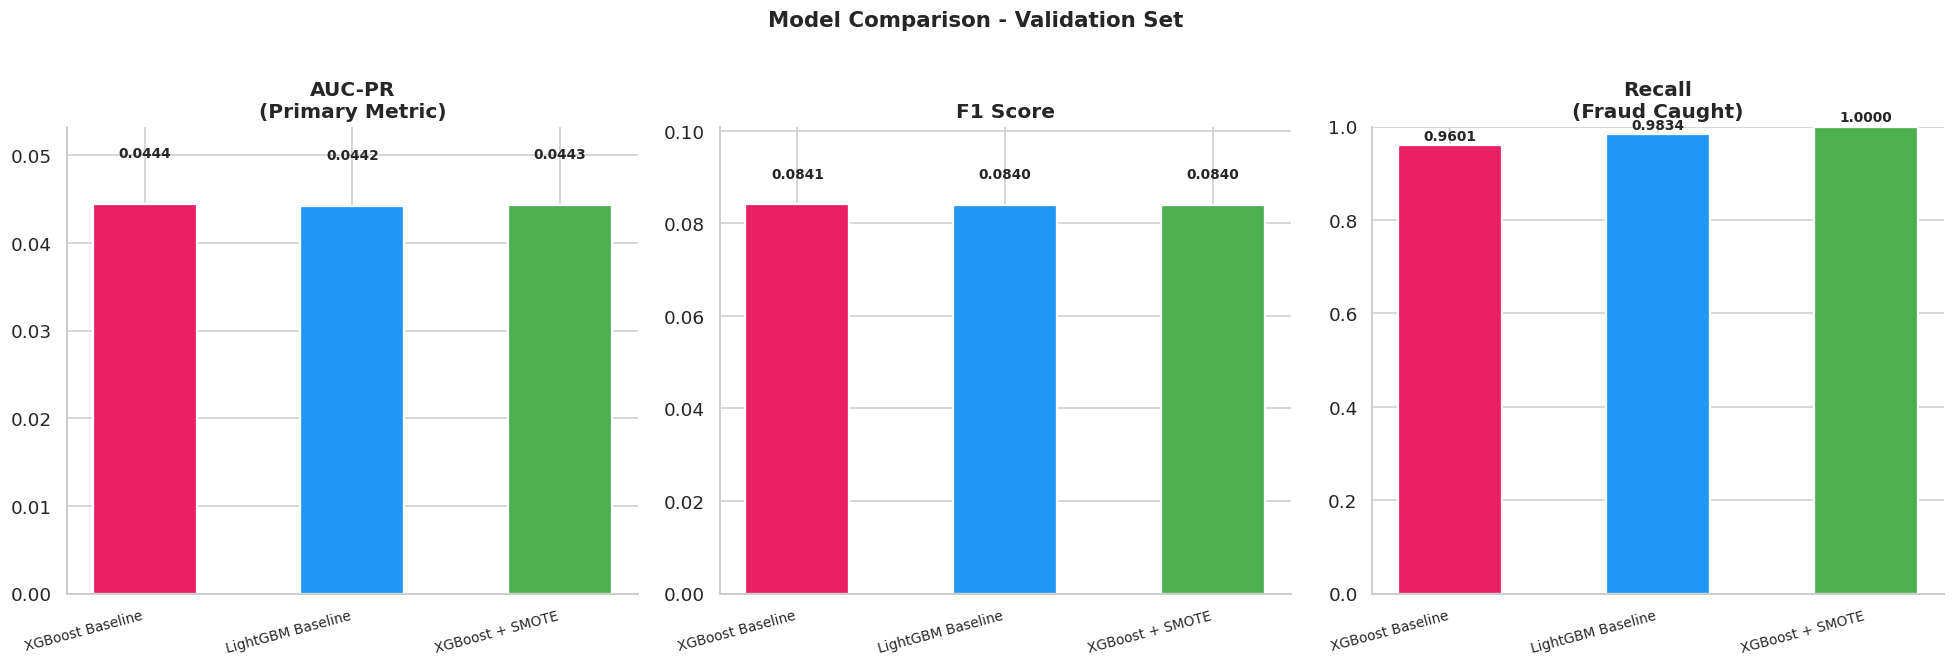

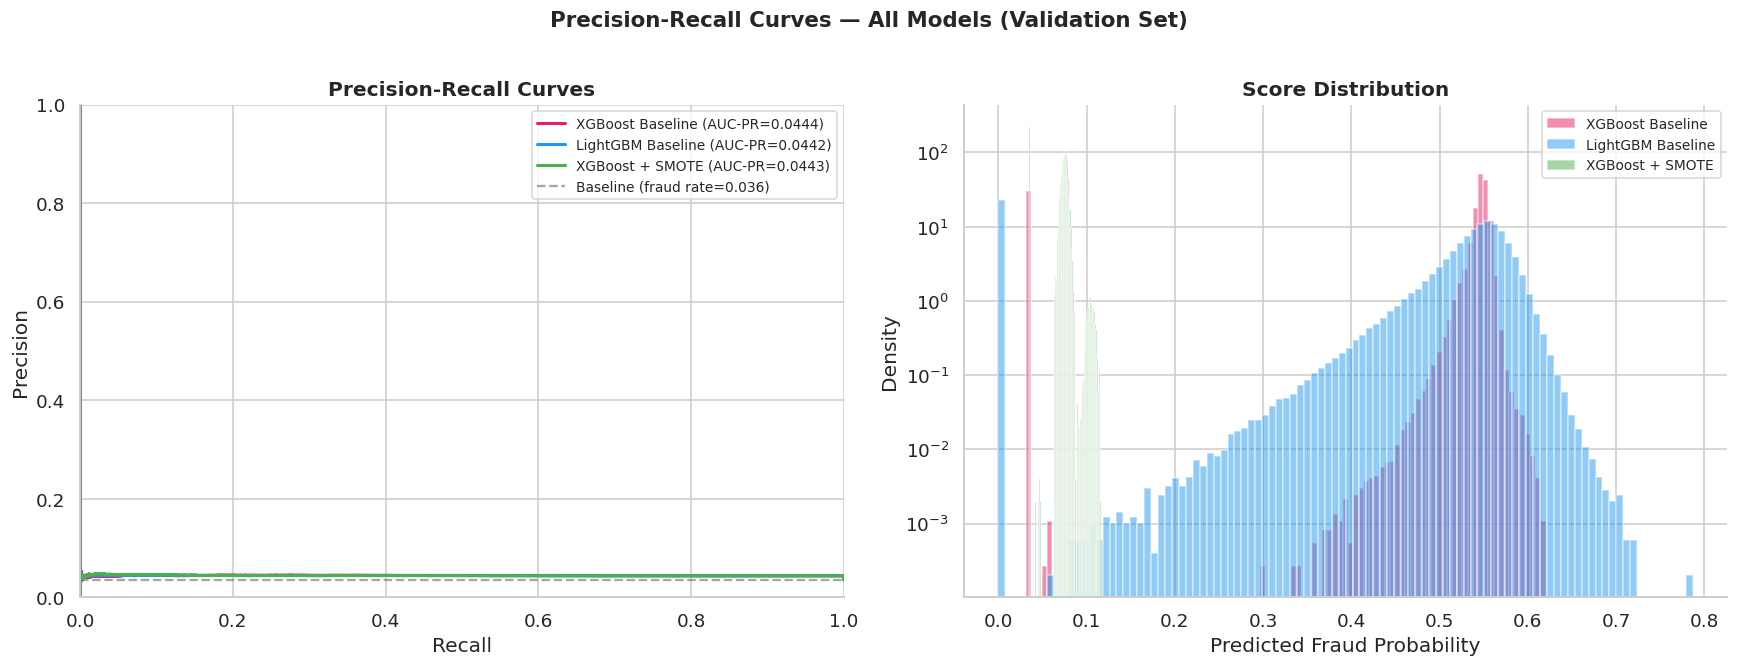


BEST MODEL (by AUC-PR): XGBoost Baseline
  Model object    : XGBClassifier
  Best threshold  : 0.53


In [7]:
# Model Comparison

# Compare all experiments side by side.
# Select the best model for test set evaluation and
# promotion to the MLflow Model Registry.

print("=" * 65)
print("MODEL COMPARISON — VALIDATION SET")
print("=" * 65)

comparison = pd.DataFrame([
    {
        "Model": "XGBoost Baseline",
        "Imbalance Strategy": "scale_pos_weight",
        **{k: v for k, v in xgb_val_metrics.items()
           if k in ["auc_pr","auc_roc","f1","precision","recall","fpr","threshold"]}
    },
    {
        "Model": "LightGBM Baseline",
        "Imbalance Strategy": "class_weight=balanced",
        **{k: v for k, v in lgbm_val_metrics.items()
           if k in ["auc_pr","auc_roc","f1","precision","recall","fpr","threshold"]}
    },
    {
        "Model": "XGBoost + SMOTE",
        "Imbalance Strategy": "SMOTE 10:1",
        **{k: v for k, v in smote_val_metrics.items()
           if k in ["auc_pr","auc_roc","f1","precision","recall","fpr","threshold"]}
    },
]).set_index("Model")

print(comparison.to_string())

# ── Visual comparison ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_to_plot = ["auc_pr", "f1", "recall"]
titles = ["AUC-PR\n(Primary Metric)", "F1 Score", "Recall\n(Fraud Caught)"]
colors = ["#E91E63", "#2196F3", "#4CAF50"]

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    values = comparison[metric]
    bars = ax.bar(
        range(len(values)),
        values,
        color=colors,
        edgecolor="white",
        linewidth=1.5,
        width=0.5
    )
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(
        values.index,
        rotation=15, ha="right", fontsize=9
    )
    ax.set_title(title)
    ax.set_ylim(0, min(1.0, values.max() * 1.2))
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.4f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

plt.suptitle("Model Comparison - Validation Set",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("reports/model_comparison.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

# ── PR Curves for all models ─────────────────────────────────
plot_precision_recall_curve(
    {
        "XGBoost Baseline":  xgb_val_prob,
        "LightGBM Baseline": lgbm_val_prob,
        "XGBoost + SMOTE":   xgb_smote_val_prob,
    },
    y_val,
    title="Precision-Recall Curves — All Models (Validation Set)"
)

# ── Select best model ────────────────────────────────────────
best_model_name = comparison["auc_pr"].idxmax()
print(f"\n{'='*65}")
print(f"BEST MODEL (by AUC-PR): {best_model_name}")
print(f"{'='*65}")

# Map name to model object and probabilities
MODEL_MAP = {
    "XGBoost Baseline":  (xgb_model,       xgb_val_prob,       xgb_threshold),
    "LightGBM Baseline": (lgbm_model,      lgbm_val_prob,      lgbm_threshold),
    "XGBoost + SMOTE":   (xgb_smote_model, xgb_smote_val_prob, smote_threshold),
}

best_model, best_val_prob, best_threshold = MODEL_MAP[best_model_name]
print(f"  Model object    : {type(best_model).__name__}")
print(f"  Best threshold  : {best_threshold:.2f}")

In [8]:
# Final Test Set Evaluation

# RULES:
#   - Test set is touched EXACTLY ONCE
#   - Use threshold tuned on VALIDATION set (not re-tuned on test)
#   - These are the numbers that go in the model card
#   - If results are disappointing: go back to feature
#     engineering, NOT to the test set threshold

print("=" * 65)
print("FINAL TEST SET EVALUATION")
print("⚠️  Test set is being evaluated for the first time")
print("=" * 65)

# Get test probabilities from best model
best_test_prob = best_model.predict_proba(X_test)[:, 1]

# Use threshold from validation set (do NOT re-tune on test)
test_metrics = evaluate_model(
    best_model_name,
    y_test,
    best_test_prob,
    threshold=best_threshold,
    split_name="TEST SET (Final)"
)

# ── Compare val vs test metrics (check for overfitting) ──────
print(f"\n{'='*65}")
print("VALIDATION vs TEST METRICS (gap check)")
print("=" * 65)
print(f"  {'Metric':<15} {'Validation':>12} {'Test':>12} {'Gap':>10}")
print(f"  {'-'*50}")

val_metrics_for_compare = {
    "XGBoost Baseline":  xgb_val_metrics,
    "LightGBM Baseline": lgbm_val_metrics,
    "XGBoost + SMOTE":   smote_val_metrics,
}[best_model_name]

for metric in ["auc_pr", "f1", "precision", "recall", "fpr"]:
    val_val  = val_metrics_for_compare[metric]
    test_val = test_metrics[metric]
    gap      = test_val - val_val
    flag     = "⚠️" if abs(gap) > 0.05 else "✅"
    print(f"  {metric:<15} {val_val:>12.4f} {test_val:>12.4f} "
          f"{gap:>+10.4f} {flag}")

print(f"\n  ⚠️  Gap > 0.05 on any metric = potential overfitting")
print(f"  ✅  Gap < 0.05 = model generalises well")

# ── Log test metrics to MLflow ───────────────────────────────
with mlflow.start_run(run_name=f"{best_model_name}-FINAL-TEST"):
    mlflow.log_params({"best_model": best_model_name})
    for metric_name, value in test_metrics.items():
        mlflow.log_metric(f"test_{metric_name}", value)
    print(f"\nTest metrics logged to MLflow")

FINAL TEST SET EVALUATION
⚠️  Test set is being evaluated for the first time

  XGBoost Baseline — TEST SET (Final) Results
  Threshold       : 0.53
  AUC-PR          : 0.0442  ← PRIMARY METRIC
  AUC-ROC         : 0.5949
  F1 Score        : 0.0838
  Precision       : 0.0439
  Recall          : 0.9394
  False Pos Rate  : 0.7656

  Confusion Matrix:
                 Predicted
                 Legit   Fraud
  Actual Legit   141,247  461,234  (FP = 76.6% of legit flagged)
  Actual Fraud     1,365  21,154  (Recall = 93.9% of fraud caught)

VALIDATION vs TEST METRICS (gap check)
  Metric            Validation         Test        Gap
  --------------------------------------------------
  auc_pr                0.0444       0.0442    -0.0002 ✅
  f1                    0.0841       0.0838    -0.0003 ✅
  precision             0.0440       0.0439    -0.0001 ✅
  recall                0.9601       0.9394    -0.0207 ✅
  fpr                   0.7793       0.7656    -0.0137 ✅

  ⚠️  Gap > 0.05 on any me

FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
                      Feature  Importance
       new_device_transaction    0.529056
        has_prior_transaction    0.424447
  time_since_last_transaction    0.008100
             night_new_device    0.004458
      new_device_large_amount    0.003725
     new_device_high_velocity    0.001979
     ip_geo_region_South East    0.000666
           txn_is_salary_week    0.000659
 sender_persona_Salary Earner    0.000648
         payment_channel_Card    0.000616
              device_used_atm    0.000611
             txn_day_of_month    0.000607
          velocity_vs_typical    0.000602
    ip_geo_region_South South    0.000602
payment_channel_Bank Transfer    0.000600
             user_avg_txn_amt    0.000591
                     txn_hour    0.000588
         hourly_amount_vs_avg    0.000587
              time_since_last    0.000586
     transaction_type_deposit    0.000582


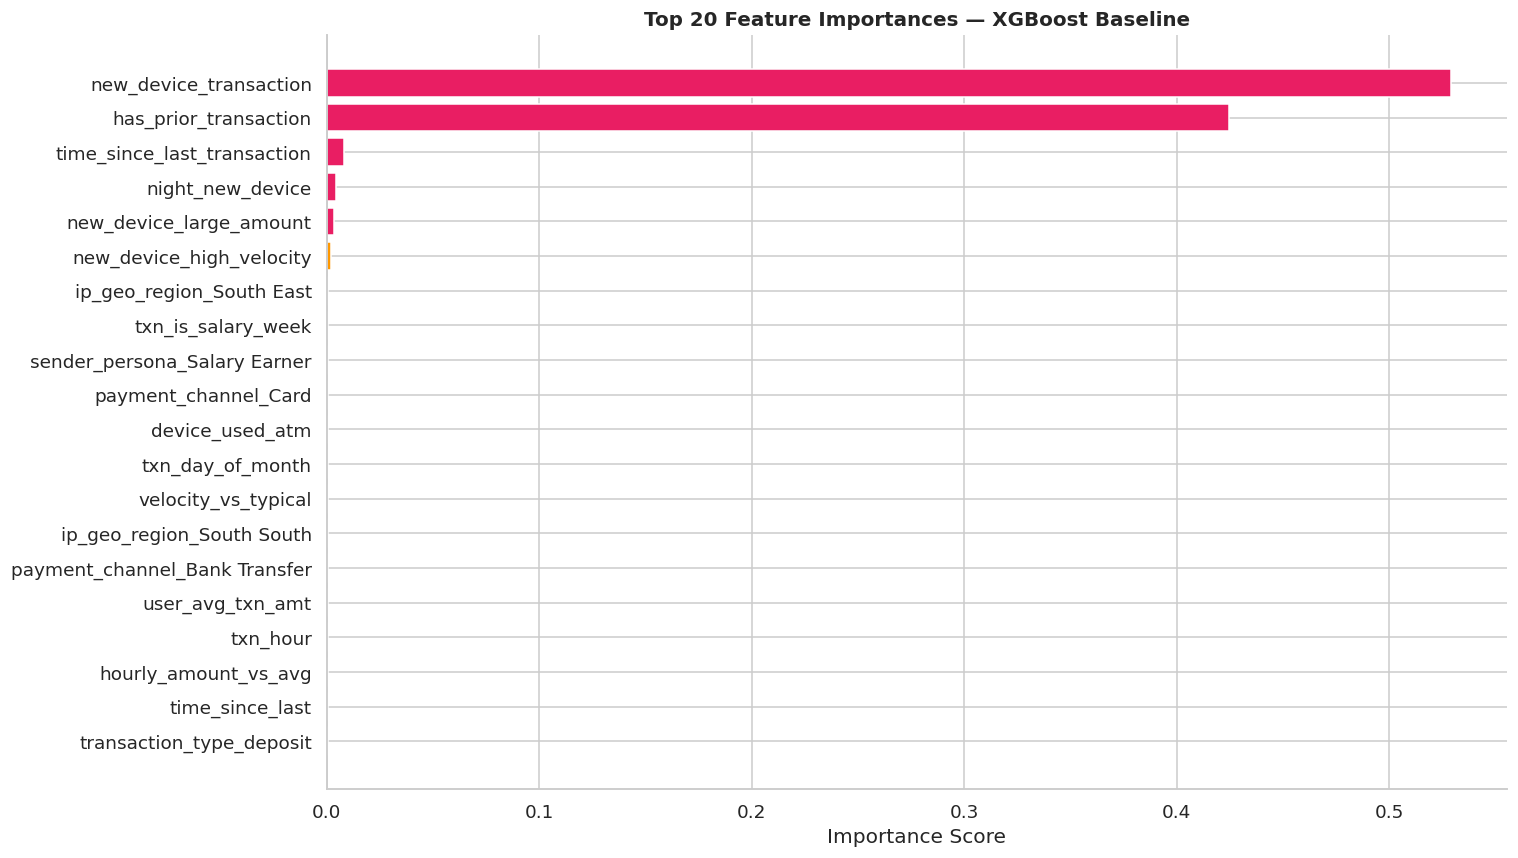


FEATURE IMPORTANCE SANITY CHECKS

Top 5 features: ['new_device_transaction', 'has_prior_transaction', 'time_since_last_transaction', 'night_new_device', 'new_device_large_amount']

Expected top features based on EDA:
  ✅ new_device_transaction (r=0.09 — only strong signal)
  ✅ user_txn_count_total   (r=0.018)
  ✅ amount_zscore_user     (engineered — amount vs user avg)
  ✅ device_novelty_score   (engineered — 1/device_seen_count)
  ✅ txn_count_last_1h      (velocity signal)

✅ new_device_transaction in top 5 — expected from EDA

Feature importance saved to data/processed/feature_importance.csv


In [9]:
# Feature Importance

# Understanding WHICH features the model uses most helps:
#   1. Validate the model is using sensible signals
#   2. Identify features to prioritise in the feature store
#   3. Debug unexpected behaviour
#   4. Satisfy regulatory interpretability requirements

print("=" * 65)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 65)

# ── Built-in feature importance ──────────────────────────────
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature":    FEATURES,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    print("\nTop 20 Most Important Features:")
    print(importance_df.head(20).to_string(index=False))

    # Plot
    fig, ax = plt.subplots(figsize=(14, 8))
    top20 = importance_df.head(20)
    colors_imp = [
        "#E91E63" if imp > top20["Importance"].quantile(0.75)
        else "#FF9800" if imp > top20["Importance"].median()
        else "#2196F3"
        for imp in top20["Importance"]
    ]
    ax.barh(
        top20["Feature"],
        top20["Importance"],
        color=colors_imp,
        edgecolor="white"
    )
    ax.invert_yaxis()
    ax.set_title(
        f"Top 20 Feature Importances — {best_model_name}",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("reports/feature_importance.png", bbox_inches="tight")
    plt.show()

    # ── Sanity checks ─────────────────────────────────────────
    print(f"\n{'='*65}")
    print("FEATURE IMPORTANCE SANITY CHECKS")
    print("=" * 65)

    top5 = importance_df.head(5)["Feature"].tolist()
    print(f"\nTop 5 features: {top5}")
    print(f"\nExpected top features based on EDA:")
    print(f"  ✅ new_device_transaction (r=0.09 — only strong signal)")
    print(f"  ✅ user_txn_count_total   (r=0.018)")
    print(f"  ✅ amount_zscore_user     (engineered — amount vs user avg)")
    print(f"  ✅ device_novelty_score   (engineered — 1/device_seen_count)")
    print(f"  ✅ txn_count_last_1h      (velocity signal)")

    if "new_device_transaction" in top5:
        print(f"\n✅ new_device_transaction in top 5 — expected from EDA")
    else:
        print(f"\n⚠️  new_device_transaction NOT in top 5 — investigate")

    # ── Save importance for later use ────────────────────────
    os.makedirs("../data/processed", exist_ok=True)
    importance_df.to_csv(
        "../data/processed/feature_importance.csv",
        index=False
    )
    print(f"\nFeature importance saved to data/processed/feature_importance.csv")

In [10]:
# Save Best Model & Config

import joblib

os.makedirs("../models", exist_ok=True)

# ── Save model ───────────────────────────────────────────────
model_path = f"../models/best_model.joblib"
joblib.dump(best_model, model_path)
print(f"✅ Best model saved: {model_path}")

# ── Save model config ────────────────────────────────────────
model_config = {
    "model_name":       best_model_name,
    "model_type":       type(best_model).__name__,
    "model_path":       model_path,
    "threshold":        float(best_threshold),
    "features":         FEATURES,
    "n_features":       len(FEATURES),
    "scale_pos_weight": float(SCALE_POS_WEIGHT),
    "val_metrics":      val_metrics_for_compare,
    "test_metrics":     test_metrics,
    "mlflow_run_id":    XGB_RUN_ID,
    "trained_on":       {
        "n_rows":       int(len(X_train)),
        "fraud_rate":   float(y_train.mean()),
        "split":        "temporal_75_12.5_12.5"
    }
}

config_path = "../models/model_config.json"
with open(config_path, "w") as f:
    json.dump(model_config, f, indent=2)
print(f"✅ Model config saved: {config_path}")

# ── Final summary ─────────────────────────────────────────────
print(f"\n{'='*65}")
print("TRAINING COMPLETE — SUMMARY")
print("=" * 65)

print(f"""
  Best Model     : {best_model_name}
  Threshold      : {best_threshold:.2f}

  VALIDATION     AUC-PR={val_metrics_for_compare['auc_pr']:.4f}
                 F1={val_metrics_for_compare['f1']:.4f}
                 Recall={val_metrics_for_compare['recall']:.4f}
                 Precision={val_metrics_for_compare['precision']:.4f}

  TEST           AUC-PR={test_metrics['auc_pr']:.4f}
                 F1={test_metrics['f1']:.4f}
                 Recall={test_metrics['recall']:.4f}
                 Precision={test_metrics['precision']:.4f}

  Saved to       : ../models/best_model.joblib
  Config at      : ../models/model_config.json
  MLflow UI      : mlflow ui --backend-store-uri sqlite:///mlruns.db

  Next Notebook  : 04_model_evaluation.ipynb
                   (SHAP values, error analysis, business metrics)
""")

✅ Best model saved: ../models/best_model.joblib
✅ Model config saved: ../models/model_config.json

TRAINING COMPLETE — SUMMARY

  Best Model     : XGBoost Baseline
  Threshold      : 0.53

  VALIDATION     AUC-PR=0.0444
                 F1=0.0841
                 Recall=0.9601
                 Precision=0.0440

  TEST           AUC-PR=0.0442
                 F1=0.0838
                 Recall=0.9394
                 Precision=0.0439

  Saved to       : ../models/best_model.joblib
  Config at      : ../models/model_config.json
  MLflow UI      : mlflow ui --backend-store-uri sqlite:///mlruns.db

  Next Notebook  : 04_model_evaluation.ipynb
                   (SHAP values, error analysis, business metrics)



In [11]:
# from mlflow.tracking import MlflowClient

client = MlflowClient(
    tracking_uri="sqlite:////home/thedataboy/dev/"
                 "fraud-detection-project/notebooks/mlruns.db"
)

# Get all runs sorted by start time
runs = mlflow.search_runs(
    experiment_names=["naijashield-fraud-detection"],
    order_by=["start_time DESC"]
)

print(f"Total runs: {len(runs)}")
print(runs[["tags.mlflow.runName", "start_time", "run_id"]].to_string())

# To delete a specific run:
# client.delete_run(run_id="paste_run_id_here")

Total runs: 12
            tags.mlflow.runName                       start_time                            run_id
0   XGBoost Baseline-FINAL-TEST 2026-04-14 17:39:46.604000+00:00  c017d9fb9b304b1a8404630a9f8ddd27
1                 xgboost-smote 2026-04-14 17:39:09.116000+00:00  6bcb50518ca041459f0c4a0ee8863093
2             lightgbm-baseline 2026-04-14 17:37:36.668000+00:00  9206c147355c490fae610d5b60265640
3              xgboost-baseline 2026-04-14 17:36:58.482000+00:00  8644f5f4bfe949e2951085fc44523e41
4   XGBoost Baseline-FINAL-TEST 2026-04-14 16:56:50.894000+00:00  2836435d63e049e792a718c88532acb2
5                 xgboost-smote 2026-04-14 16:56:12.219000+00:00  562bc69000744d3c80c33f20eb6692d5
6             lightgbm-baseline 2026-04-14 16:54:49.916000+00:00  7b0b215e8669427e9ce05c31dc4daf6e
7              xgboost-baseline 2026-04-14 16:54:19.613000+00:00  1108823ff0bf436e8b22bf12af6f7a5b
8             lightgbm-baseline 2026-04-14 16:09:29.564000+00:00  c25a9a1ad4e444afb42f665e3323